<a href="https://colab.research.google.com/github/thekylebell/Momentum-Models/blob/main/v3_vol_scaled_momentum_macro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas_datareader.data as web
from datetime import datetime

# --- 1. INTERACTIVE UI SETUP ---
ticker_input = widgets.Text(value='SPY', description='Asset:')
bench_input = widgets.Dropdown(
    options=[('S&P 500', 'SPY'), ('Gold', 'GLD'), ('Bitcoin', 'BTC-USD')],
    value='SPY', description='Bench:'
)
capital_input = widgets.FloatText(value=10000.0, description='Start $:', min=1.0, max=1e9)
vol_input = widgets.FloatSlider(value=0.12, min=0.05, max=0.40, step=0.01, description='Target Vol:')
start_date_input = widgets.DatePicker(value=pd.to_datetime('2015-01-01'), description='Start Date:')
run_button = widgets.Button(description="Execute Model", button_style='success')
output = widgets.Output()

ui = widgets.VBox([
    widgets.HBox([ticker_input, bench_input, capital_input]),
    widgets.HBox([vol_input, start_date_input]),
    run_button
])

# --- 2. THE BACKTEST ENGINE ---
def run_backtest(b):
    global prices, tbill_daily
    with output:
        clear_output(wait=True)

        # Inputs
        ticker = ticker_input.value
        bench_ticker = bench_input.value
        start_cap = capital_input.value
        t_vol = vol_input.value
        start_str = start_date_input.value.strftime('%Y-%m-%d')

        print(f"Fetching data for {ticker}, {bench_ticker}, T-Bills, and CPI...")

        # A. Data Acquisition (Asset, Benchmark, 13-Week T-Bill)
        # ^IRX is the 13-week Treasury Bill yield
        data = yf.download([ticker, bench_ticker, '^IRX'], start=start_str, auto_adjust=False)

        # Handle yfinance MultiIndex
        if isinstance(data.columns, pd.MultiIndex):
            prices = data['Adj Close'].copy()
        else:
            prices = data[['Adj Close']].copy()

        prices = prices.dropna(subset=[ticker, '^IRX'])

        # B. Macro Data Acquisition (CPI from FRED)
        try:
            cpi = web.DataReader('CPIAUCSL', 'fred', start=start_str)
            cpi_daily = cpi.resample('D').ffill().pct_change(fill_method=None).fillna(0)
        except:
            print("Error fetching CPI. Defaulting to 3% annual estimate.")
            cpi_daily = pd.Series(0.03/252, index=prices.index)

        # C. Strategy Logic
        # 1. Momentum Signal (252-day)
        returns = prices[ticker].pct_change(fill_method=None)
        momentum = (prices[ticker] / prices[ticker].shift(252)) - 1
        signal = (momentum > 0).astype(int)

        # 2. Risk Engine (Volatility Scaling)
        realized_vol = returns.rolling(20).std() * np.sqrt(252)
        vol_weight = (t_vol / realized_vol).clip(upper=1.0)
        scaled_pos = (signal * vol_weight).shift(1)  # Lagging to prevent bias

        # 3. Cash Management (T-Bills)
        # ^IRX is an annualized percentage. Convert to daily decimal.
        tbill_daily = (prices['^IRX'] / 100) / 252

        # D. Performance Math
        # Nominal Portfolio Return = (Position * Asset) + (Cash * T-Bill)
        nominal_strat_ret = (scaled_pos * returns) + ((1 - scaled_pos) * tbill_daily)
        bench_ret = prices[bench_ticker].pct_change(fill_method=None)

        # Real Return Adjustment (Purchasing Power)
        # 1 + Real = (1 + Nominal) / (1 + Inflation)
        inf_daily = cpi_daily.reindex(nominal_strat_ret.index, method='ffill').iloc[:, 0]
        real_strat_ret = ((1 + nominal_strat_ret) / (1 + inf_daily)) - 1
        real_bench_ret = ((1 + bench_ret) / (1 + inf_daily)) - 1
        real_bench_wealth = start_cap * (1 + real_bench_ret.fillna(0)).cumprod()
        # E. Wealth Curves
        nominal_wealth = start_cap * (1 + nominal_strat_ret.fillna(0)).cumprod()
        real_wealth = start_cap * (1 + real_strat_ret.fillna(0)).cumprod()
        bench_wealth = start_cap * (1 + bench_ret.fillna(0)).cumprod()

        # --- CALCULATE DRAWDOWN ---
        # We use the Nominal Wealth curve for this
        rolling_max = nominal_wealth.cummax()
        drawdown = (nominal_wealth - rolling_max) / rolling_max
        max_drawdown = drawdown.min()
        # Benchmark Drawdown (for MAR comparison)
        bench_rolling_max = bench_wealth.cummax()
        bench_drawdown_curve = (bench_wealth - bench_rolling_max) / bench_rolling_max
        bench_max_drawdown = bench_drawdown_curve.min()

        # --- 3. VISUALIZATION ---
        # Create two subplots: one for growth, one for position size
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

        # 1st Plot: Wealth
        ax1.plot(nominal_wealth, label='Strategy (Nominal)', color='teal')
        ax1.plot(real_wealth, label='Strategy (Real)', color='orange', linestyle='--')
        ax1.plot(bench_wealth, label=f'Benchmark ({bench_ticker})', color='gray', linestyle=':')
        ax1.plot(real_bench_wealth, label=f'Benchmark Real ({bench_ticker})', color='lightgray', linestyle=':')
        ax1.set_ylabel("Portfolio Value ($)")
        ax1.set_yscale('log')
        ax1.legend()

        # 2nd Plot: The "Dimmer Switch" (Position Size)
        ax2.fill_between(scaled_pos.index, 0, scaled_pos, color='teal', alpha=0.3, label='Market Exposure')
        ax2.set_ylabel("Exposure (0.0 to 1.0)")
        ax2.set_ylim(0, 1.1)
        ax2.legend()

        plt.suptitle(f"Strategy Analysis: {ticker}", fontsize=16)

        # Third Plot
        ax3.fill_between(drawdown.index, 0, drawdown * 100,
                         where=(drawdown >= -0.20), color='red', alpha=0.3, label='< 20% Drawdown')
        ax3.fill_between(drawdown.index, 0, drawdown * 100,
                         where=(drawdown < -0.20), color='darkred', alpha=0.7, label='> 20% Drawdown')
        ax3.axhline(y=-20, color='darkred', linestyle='--', linewidth=0.8, alpha=0.6)
        ax3.legend(fontsize=8)
        ax3.set_ylabel("Drawdown (%)")
        ax3.set_title("Portfolio Drawdown (Peak-to-Trough)", fontsize=10)
        ax3.grid(True, alpha=0.2)

        plt.tight_layout()
        plt.show()

        # --- 4. METRICS REPORT ---
        def get_sharpe(r): return (r.mean() / r.std()) * np.sqrt(252) if r.std() != 0 else 0

        total_nominal = nominal_wealth.iloc[-1]
        total_real = real_wealth.iloc[-1]

        # 1. Calculate CAGR (Annualized Return)
        total_days = (nominal_wealth.index[-1] - nominal_wealth.index[0]).days
        years = total_days / 365.25
        cagr = (nominal_wealth.iloc[-1] / start_cap)**(1/years) - 1
        bench_cagr = (bench_wealth.iloc[-1] / start_cap)**(1/years) - 1
        bench_mar = bench_cagr / abs(bench_max_drawdown) if bench_max_drawdown != 0 else 0
        # Calmar uses only the last 36 months, unlike MAR which uses full history
        calmar_wealth = nominal_wealth.last('1096D')  # ~36 months
        calmar_rolling_max = calmar_wealth.cummax()
        calmar_dd = ((calmar_wealth - calmar_rolling_max) / calmar_rolling_max).min()
        calmar_days = (calmar_wealth.index[-1] - calmar_wealth.index[0]).days
        calmar_cagr = (calmar_wealth.iloc[-1] / calmar_wealth.iloc[0])**(365.25/calmar_days) - 1
        calmar_ratio = calmar_cagr / abs(calmar_dd) if calmar_dd != 0 else 0
        # 2. Calculate MAR Ratio
        # We use abs() because Max Drawdown is a negative number
        mar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else 0

        # 3. Print statements
        print(f"Strategy CAGR: {cagr*100:.2f}% | Benchmark CAGR: {bench_cagr*100:.2f}% | Aim is to beat benchmark")
        print(f"Strategy MAR: {mar_ratio:.2f} | Benchmark MAR: {bench_mar:.2f} | > 0.5: Good | > 1.0: Excellent | > 2.0: Holy Grail")
        print(f"Strategy Calmar Ratio (3yr): {calmar_ratio:.2f} | > 0.5: Good | > 1.0: Excellent | > 2.0: Holy Grail")
        print("\n" + "="*30)
        print(f"FINAL PORTFOLIO VALUE: ${total_nominal:,.2f}")
        print(f"REAL PURCHASING POWER: ${total_real:,.2f}")
        print(f"LOSS TO INFLATION: ${(total_nominal - total_real):,.2f}")
        print("-"*30)
        print(f"Strategy Sharpe Ratio: {get_sharpe(nominal_strat_ret.dropna()):.2f} | > 1.0: Good | > 2.0: Very Good | > 3.0: Elite")
        print(f"Benchmark Sharpe Ratio: {get_sharpe(bench_ret.dropna()):.2f}")
        print("="*30)
        print(f"Max Strategy Drawdown: {max_drawdown*100:.2f}%")
        print('='*30)

run_button.on_click(run_backtest)
display(ui, output)

Output()

Running Parameter Sweep... this may take a moment.


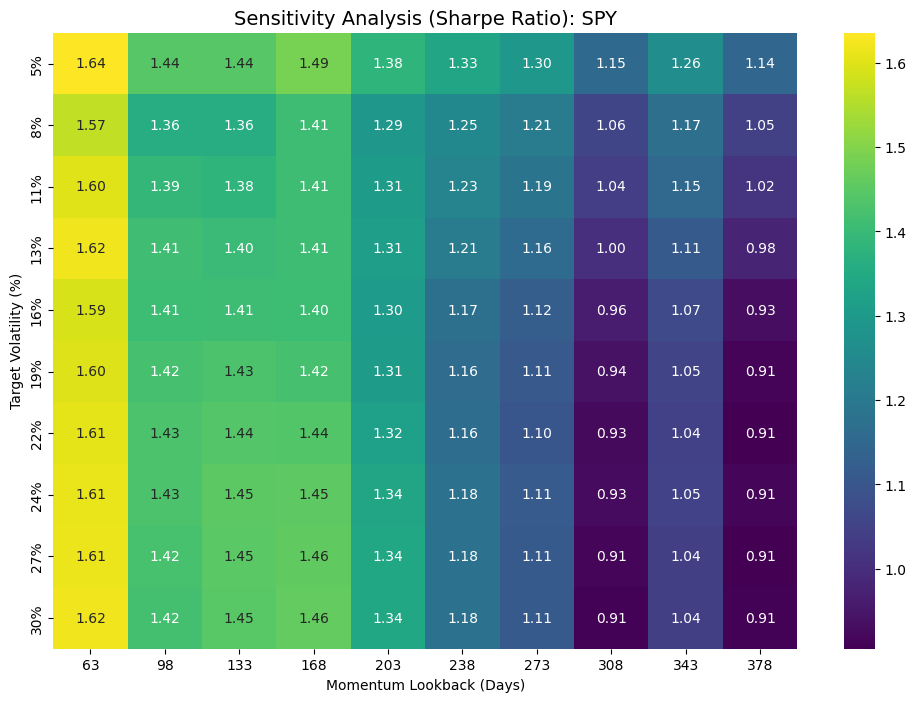

In [40]:
import seaborn as sns

def run_heatmap_analysis():
    if 'prices' not in globals():
        print("Error: Please click 'Execute Model' in the first cell before running the heatmap.")
        return
    # 1. Define the ranges to test
    # Testing Lookbacks from 3 months (63 days) to 1.5 years (378 days)
    lookbacks = np.linspace(63, 378, 10).astype(int)
    # Testing Target Vols from 5% to 30%
    vols = np.linspace(0.05, 0.30, 10)

    # Use the data already downloaded in the main cell to save time
    # (Assuming 'prices' and 'tbill_daily' exist from your main run)
    asset_rets = prices[ticker_input.value].pct_change()
    tbill = (prices['^IRX'] / 100) / 252

    # Grid to store results (Sharpe Ratio is the best metric for this)
    heatmap_data = np.zeros((len(vols), len(lookbacks)))

    print("Running Parameter Sweep... this may take a moment.")

    for i, v in enumerate(vols):
        for j, l in enumerate(lookbacks):
            # Calculate Signal for this specific lookback
            sig = (prices[ticker_input.value] > prices[ticker_input.value].shift(l)).astype(int)
            # Calculate Vol Weight for this specific target vol
            r_vol = asset_rets.rolling(20).std() * np.sqrt(252)
            weight = (v / r_vol).clip(upper=1.0).shift(1)

            # Strategy Return
            p_ret = (weight * asset_rets * sig) + ((1 - (weight * sig)) * tbill)

            # Calculate Sharpe Ratio
            if p_ret.std() != 0:
                heatmap_data[i, j] = (p_ret.mean() / p_ret.std()) * np.sqrt(252)
            else:
                heatmap_data[i, j] = 0

    # 3. Plotting the Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f",
                xticklabels=lookbacks, yticklabels=[f"{v*100:.0f}%" for v in vols],
                cmap='viridis')
    plt.title(f"Sensitivity Analysis (Sharpe Ratio): {ticker_input.value}", fontsize=14)
    plt.xlabel("Momentum Lookback (Days)")
    plt.ylabel("Target Volatility (%)")
    plt.show()

# Run the heatmap
run_heatmap_analysis()